In [7]:
import polars as pl
import matplotlib.pyplot as plt
from procompa import get_project_root
from procompa.helpers import make_pairs, clean_identifiers
PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

## Explore Homomultimer matching

In [4]:
#pdb_homomultimers = pl.read_csv (data_dir / "Homomltimer/homomultimers.csv")

## Explore poooled and Pairf AF df

In [8]:
import pooled_ppi.yeast_pools as yp

In [9]:
af3_id = 'q12099'
yp.get_models(filters=[('af3_id1', '==', af3_id), ('af3_id2', '==', af3_id)])

,af3_id1,af3_id2,chain_id1,chain_id2,input_name,input_type,batch_id,seed,sample,ranking_score,chain_pair_iptm,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean,db_id1,db_id2
0,q12099,q12099,A,B,q12099_q12099,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,0,0.163229,0.11,26.80,26.96,26.880,q12099_q12099_0_A,q12099_q12099_0_B
1,q12099,q12099,A,B,q12099_q12099,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,1,0.165200,0.12,26.60,26.87,26.735,q12099_q12099_1_A,q12099_q12099_1_B
2,q12099,q12099,A,B,q12099_q12099,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,2,0.164353,0.11,26.41,26.66,26.535,q12099_q12099_2_A,q12099_q12099_2_B
3,q12099,q12099,A,B,q12099_q12099,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,3,0.178349,0.10,29.44,29.50,29.470,q12099_q12099_3_A,q12099_q12099_3_B
4,q12099,q12099,A,B,q12099_q12099,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,4,0.156917,0.10,27.94,28.06,28.000,q12099_q12099_4_A,q12099_q12099_4_B
5,q12099,q12099,L,M,d9be9ab82d28004ee7a599fb2b81336ee4fd5801,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,0,0.332547,0.09,31.12,31.21,31.165,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_0_L,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_0_M
6,q12099,q12099,L,M,d9be9ab82d28004ee7a599fb2b81336ee4fd5801,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,1,0.330250,0.09,30.72,30.87,30.795,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_1_L,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_1_M
7,q12099,q12099,L,M,d9be9ab82d28004ee7a599fb2b81336ee4fd5801,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,2,0.344126,0.09,30.43,30.73,30.580,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_2_L,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_2_M
8,q12099,q12099,L,M,d9be9ab82d28004ee7a599fb2b81336ee4fd5801,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,3,0.321039,0.09,30.68,30.76,30.720,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_3_L,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_3_M
9,q12099,q12099,L,M,d9be9ab82d28004ee7a599fb2b81336ee4fd5801,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,4,0.322359,0.09,29.45,30.12,29.785,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_4_L,d9be9ab82d28004ee7a599fb2b81336ee4fd5801_4_M


In [2]:
# extract first model (sample==0) from pair and pool
#models = yp.get_models(filters=[('af3_id1', '==', af3_id), ('af3_id2', '==', af3_id), ('sample', '==', 0)])
id_1 ='p49017'
id_2 = 'q05779'
models = yp.get_models(filters=[('af3_id1', '==', id_1), ('af3_id2', '==', id_2)])
models
     

,af3_id1,af3_id2,chain_id1,chain_id2,input_name,input_type,batch_id,seed,sample,ranking_score,chain_pair_iptm,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean,db_id1,db_id2
0,p49017,q05779,F,I,0c805b37bc9758e1067ab099868ab25671d8181c,pool,26.03/euler-std-a100-r3-2,4,0,0.330434,0.37,9.63,10.35,9.990,0c805b37bc9758e1067ab099868ab25671d8181c_0_F,0c805b37bc9758e1067ab099868ab25671d8181c_0_I
1,p49017,q05779,F,I,0c805b37bc9758e1067ab099868ab25671d8181c,pool,26.03/euler-std-a100-r3-2,4,1,0.348989,0.37,9.75,10.91,10.330,0c805b37bc9758e1067ab099868ab25671d8181c_1_F,0c805b37bc9758e1067ab099868ab25671d8181c_1_I
2,p49017,q05779,F,I,0c805b37bc9758e1067ab099868ab25671d8181c,pool,26.03/euler-std-a100-r3-2,4,2,0.367957,0.37,10.74,11.62,11.180,0c805b37bc9758e1067ab099868ab25671d8181c_2_F,0c805b37bc9758e1067ab099868ab25671d8181c_2_I
3,p49017,q05779,F,I,0c805b37bc9758e1067ab099868ab25671d8181c,pool,26.03/euler-std-a100-r3-2,4,3,0.364772,0.37,9.39,9.83,9.610,0c805b37bc9758e1067ab099868ab25671d8181c_3_F,0c805b37bc9758e1067ab099868ab25671d8181c_3_I
4,p49017,q05779,F,I,0c805b37bc9758e1067ab099868ab25671d8181c,pool,26.03/euler-std-a100-r3-2,4,4,-99.666429,0.38,10.10,11.24,10.670,0c805b37bc9758e1067ab099868ab25671d8181c_4_F,0c805b37bc9758e1067ab099868ab25671d8181c_4_I
5,p49017,q05779,C,H,2254407b85b5e93fbb80f8772e7b88120d9f1daf,pool,26.04/euler-std-a100-r3-1,4,0,0.398496,0.48,6.05,8.41,7.230,2254407b85b5e93fbb80f8772e7b88120d9f1daf_0_C,2254407b85b5e93fbb80f8772e7b88120d9f1daf_0_H
6,p49017,q05779,C,H,2254407b85b5e93fbb80f8772e7b88120d9f1daf,pool,26.04/euler-std-a100-r3-1,4,1,0.396498,0.49,6.23,8.49,7.360,2254407b85b5e93fbb80f8772e7b88120d9f1daf_1_C,2254407b85b5e93fbb80f8772e7b88120d9f1daf_1_H
7,p49017,q05779,C,H,2254407b85b5e93fbb80f8772e7b88120d9f1daf,pool,26.04/euler-std-a100-r3-1,4,2,0.379834,0.48,5.97,8.50,7.235,2254407b85b5e93fbb80f8772e7b88120d9f1daf_2_C,2254407b85b5e93fbb80f8772e7b88120d9f1daf_2_H
8,p49017,q05779,C,H,2254407b85b5e93fbb80f8772e7b88120d9f1daf,pool,26.04/euler-std-a100-r3-1,4,3,0.384814,0.48,6.24,8.73,7.485,2254407b85b5e93fbb80f8772e7b88120d9f1daf_3_C,2254407b85b5e93fbb80f8772e7b88120d9f1daf_3_H
9,p49017,q05779,C,H,2254407b85b5e93fbb80f8772e7b88120d9f1daf,pool,26.04/euler-std-a100-r3-1,4,4,0.396980,0.48,6.33,8.73,7.530,2254407b85b5e93fbb80f8772e7b88120d9f1daf_4_C,2254407b85b5e93fbb80f8772e7b88120d9f1daf_4_H


In [9]:
# If you used .iloc[0], change to:
best_model = models.sort_values('ranking_score', ascending=False).iloc[[0]]

best_model 

,af3_id1,af3_id2,chain_id1,chain_id2,input_name,input_type,batch_id,seed,sample,ranking_score,chain_pair_iptm,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean,db_id1,db_id2
5,p49017,q05779,C,H,2254407b85b5e93fbb80f8772e7b88120d9f1daf,pool,26.04/euler-std-a100-r3-1,4,0,0.398496,0.48,6.05,8.41,7.23,2254407b85b5e93fbb80f8772e7b88120d9f1daf_0_C,2254407b85b5e93fbb80f8772e7b88120d9f1daf_0_H


In [7]:
#id_1, id_2 = 'p00546', 'p20438' works P00546 - P32943
id_1, id_2 = 'p0c2h9', 'p0cx44' #only have pair model

path = '/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.07/summary_models.parquet'

models = (
    pl.scan_parquet(path)
      .filter(
          ((pl.col("af3_id1") == id_1) & (pl.col("af3_id2") == id_2)) |
          ((pl.col("af3_id1") == id_2) & (pl.col("af3_id2") == id_1))
      )
      #.filter(pl.col("sample") == 0)
      .collect()
)
models


af3_id1,af3_id2,chain_id1,chain_id2,input_name,input_type,batch_id,seed,sample,ranking_score,chain_pair_iptm,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean
str,str,str,str,str,str,str,i64,i64,f64,f64,f64,f64,f64
"""p0c2h9""","""p0cx44""","""A""","""B""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,0,0.337384,0.05,30.73,30.91,30.82
"""p0c2h9""","""p0cx44""","""A""","""C""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,0,0.337384,0.07,27.43,27.54,27.485
"""p0c2h9""","""p0cx44""","""A""","""B""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,1,0.342318,0.05,30.05,30.08,30.065
"""p0c2h9""","""p0cx44""","""A""","""C""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,1,0.342318,0.07,27.55,27.8,27.675
"""p0c2h9""","""p0cx44""","""A""","""B""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,2,0.342376,0.04,31.32,31.34,31.33
"""p0c2h9""","""p0cx44""","""A""","""C""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,2,0.342376,0.04,31.48,31.49,31.485
"""p0c2h9""","""p0cx44""","""A""","""B""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,3,0.336578,0.05,29.0,29.11,29.055
"""p0c2h9""","""p0cx44""","""A""","""C""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,3,0.336578,0.05,30.64,30.95,30.795
"""p0c2h9""","""p0cx44""","""A""","""B""","""0d83d852a65f7711b6d2b8ab9320af…","""pool""","""26.06/euler-homodimers-rtx_pro…",4,4,0.336527,0.04,31.23,31.31,31.27


In [3]:
path = '/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.07/summary_models.parquet'

t =pl.scan_parquet(path).group_by("batch_id").agg(
    pl.len().alias("n_models"),
    pl.col("input_type").first().alias("input_type"),
).sort("n_models", descending=True).collect()

In [4]:
t.write_csv('/cluster/project/beltrao/kdammer/master_thesis/tmp/batch_id_input_type.csv')

In [10]:
out_path = PRJ_ROOT/ "tmp"
for i, row in best_model.iterrows():
    path = out_path / f'{row.af3_id1}_{row.af3_id2}_{row.input_type}_{row["sample"]}.pdb'
    yp.save_predictions_db([row.db_id1, row.db_id2], str(path))
    print( path, 'written')

0 2254407b85b5e93fbb80f8772e7b88120d9f1daf_0_C A
1 2254407b85b5e93fbb80f8772e7b88120d9f1daf_0_H B
/cluster/project/beltrao/kdammer/master_thesis/tmp/p49017_q05779_pool_0.pdb written


In [4]:
import sqlite_utils
db = sqlite_utils.Database(yp.get_path('models.sqlite'))
try:
    db['models'].get('some_id_that_does_not_exist_xyz')
except Exception as e:
    print(type(e), e)

<class 'sqlite_utils.db.NotFoundError'> 


In [ ]:
#!/usr/bin/env python3
"""
Verify the "two different databases" hypothesis before patching s2_run_CombFold.sbatch.

Hypothesis (from a parallel debugging session, consistent with our own findings):
  - The sbatch script reads pairwise structures from a FLAT foldcomp file:
        {POOLED_PPI_DB}/predictions-db/predictions-db
    via foldcomp.open(FC_DB, ids=[key1, key2])
  - `yp.save_predictions_db()` (the helper you used to successfully extract
    p00431_p00431_0_A/_B) apparently reads from a DIFFERENT store — possibly
    a SQLite file (models.sqlite) in the same data-26.07 directory — that is
    more complete for pair-type samples.

We already confirmed independently: summary_models.parquet lists 5 pair rows
for p00431 (samples 0-4), and NONE of the 5 corresponding keys exist in the
flat foldcomp file. So the sbatch script's fallback isn't a key-format bug —
it's querying the wrong physical database entirely for pair structures.

This script does NOT guess the fix yet. It inspects the real yp source and
the real SQLite schema (if any) so any patch is based on confirmed behavior,
not reverse-engineered guesses.

Run this in the SAME notebook/session where `yp` is already imported and
`yp.get_models(...)` / `yp.save_predictions_db(...)` already worked for you.
"""

import inspect
import os

print("=" * 70)
print("STEP 1: Locate the yp module and print its real source")
print("=" * 70)
try:
    import yp  # noqa: F401  (assumes already importable in your session)
    print(f"yp module file: {yp.__file__}")
    print()
except Exception as e:
    print(f"Could not import yp directly here: {e}")
    print("Run this block in the notebook where `yp` is already imported instead.")

for fn_name in ["get_models", "save_predictions_db", "load_predictions_db", "get_path", "get_data"]:
    fn = globals().get("yp")
    if fn is None:
        break
    obj = getattr(fn, fn_name, None)
    print(f"--- yp.{fn_name} ---")
    if obj is None:
        print("  (not found on yp — may be a different name, or nested in a submodule)")
        continue
    try:
        print(inspect.getsource(obj))
    except Exception as e:
        print(f"  Could not get source: {e}")
    print()

print("=" * 70)
print("STEP 2: Does models.sqlite (or any .sqlite/.db) exist in data-26.07?")
print("=" * 70)
POOLED_PPI_DB = "/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.07"
for fname in os.listdir(POOLED_PPI_DB):
    if fname.endswith((".sqlite", ".sqlite3", ".db")):
        full = os.path.join(POOLED_PPI_DB, fname)
        size_mb = os.path.getsize(full) / 1e6
        print(f"  FOUND: {full} ({size_mb:.1f} MB)")
print()
print("Full directory listing (for reference):")
for fname in sorted(os.listdir(POOLED_PPI_DB)):
    print(f"  {fname}")

print()
print("=" * 70)
print("STEP 3: Inspect the SQLite schema directly with stdlib sqlite3")
print("        (no sqlite_utils dependency needed just to look)")
print("=" * 70)
import sqlite3

sqlite_path = os.path.join(POOLED_PPI_DB, "models.sqlite")
if not os.path.exists(sqlite_path):
    # try any sqlite file found in step 2
    candidates = [f for f in os.listdir(POOLED_PPI_DB) if f.endswith((".sqlite", ".sqlite3", ".db"))]
    if candidates:
        sqlite_path = os.path.join(POOLED_PPI_DB, candidates[0])
        print(f"models.sqlite not found by that exact name; trying: {sqlite_path}")
    else:
        print("No sqlite file found in data-26.07 at all.")
        sqlite_path = None

if sqlite_path and os.path.exists(sqlite_path):
    con = sqlite3.connect(f"file:{sqlite_path}?mode=ro", uri=True)
    cur = con.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = [r[0] for r in cur.fetchall()]
    print(f"Tables: {tables}")
    print()
    for t in tables:
        cur.execute(f"PRAGMA table_info({t})")
        cols = cur.fetchall()
        print(f"--- Schema of table '{t}' ---")
        for col in cols:
            print(f"  {col}")  # (cid, name, type, notnull, dflt_value, pk)
        cur.execute(f"SELECT COUNT(*) FROM {t}")
        print(f"  Row count: {cur.fetchone()[0]}")
        print()

    print("=" * 70)
    print("STEP 4: Look up the specific pair key we know is missing from the flat DB")
    print("=" * 70)
    test_keys = ["p00431_p00431_0_A", "p00431_p00431_0_B",
                 "p00431_p00431_1_A", "p00431_p00431_4_A"]
    # We don't yet know the primary key / id column name — try the obvious ones.
    id_col_candidates = ["id", "id_", "key", "model_id", "name"]
    if "models" in tables:
        cur.execute("PRAGMA table_info(models)")
        real_cols = [c[1] for c in cur.fetchall()]
        print(f"Real columns in 'models' table: {real_cols}")
        id_col = next((c for c in id_col_candidates if c in real_cols), real_cols[0])
        print(f"Using id column guess: '{id_col}' (verify against real_cols above)")
        for key in test_keys:
            cur.execute(f"SELECT * FROM models WHERE {id_col} = ?", (key,))
            row = cur.fetchone()
            if row is not None:
                print(f"  FOUND row for {key}: {row[:3]}... (truncated)")
            else:
                print(f"  NOT FOUND: {key}")
    con.close()
else:
    print("Skipping schema inspection — no sqlite file located.")

print()
print("=" * 70)
print("NEXT STEP")
print("=" * 70)
print("Paste back:")
print("  1. The printed source of yp.get_models / yp.save_predictions_db (Step 1)")
print("  2. The real table/column names from Step 3")
print("  3. Whether Step 4 found the p00431_p00431_0_A key")
print()
print("That tells us the EXACT query the sbatch script's save_pair_pdb() should")
print("run instead of foldcomp.open() on the flat file — no more guessing at")
print("sqlite_utils / column names / decompress() return signature.")


STEP 1: Locate the yp module and print its real source
Could not import yp directly here: No module named 'yp'
Run this block in the notebook where `yp` is already imported instead.
--- yp.get_models ---
def get_models(filters=None):
    pairs = pd.read_parquet(get_path('summary_models.parquet'), filters=filters)
    pairs['db_id1'] = pairs['input_name'] + '_' + pairs['sample'].astype(str) + '_' + pairs['chain_id1']
    pairs['db_id2'] = pairs['input_name'] + '_' + pairs['sample'].astype(str) + '_' + pairs['chain_id2']
    return pairs


--- yp.save_predictions_db ---
def save_predictions_db(ids, file):
    struct = load_predictions_db(ids)
    pdbio = Bio.PDB.PDBIO()
    pdbio.set_structure(struct)
    pdbio.save(file)


--- yp.load_predictions_db ---
def load_predictions_db(ids, path='models.sqlite'):
    parser = Bio.PDB.PDBParser(QUIET=True)
    struct0 = None

    assert os.path.isfile(get_path(path))
    db = sqlite_utils.Database(get_path(path))
    for index, (id_, chain_id) in

In [ ]:
db = sqlite_utils.Database(yp.get_path('models.sqlite'))
try:
    db['models'].get('some_id_that_does_not_exist_xyz')
except Exception as e:
    print(type(e), e)

/cluster/project/beltrao/kdammer/master_thesis/.venv/lib/python3.11/site-packages/pooled_ppi/yeast_pools.py
['Bio', 'GUARANTEED_RANDOM', 'IPython', 'Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_num_rows', 'af3io', 'argparse', 'as_array', 'ast', 'bartolec2019', 'biogrid', 'cached_path', 'childs2019', 'collections', 'copy', 'csv', 'datetime', 'dispall', 'flatten', 'foldcomp', 'format_pct', 'functools', 'get_data', 'get_head', 'get_max_workers', 'get_models', 'get_pair_pdb', 'get_pairs', 'get_pairs_all_vs_all', 'get_pairs_nunique', 'get_pairs_std', 'get_pairs_std_matrix', 'get_pairs_std_matrix_corr', 'get_pairs_std_matrix_corr_pairs', 'get_path', 'get_pools_nunique', 'get_pools_total', 'get_proteins', 'glob', 'guess_prefix', 'gzip', 'hashlib', 'importlib', 'inspect', 'intact', 'io', 'itertools', 'json', 'lambourne2026', 'load_predictions_db', 'math', 'merge_af3_id', 'merge_af3_pair', 'np', 'operator', 'os', 'pa', 'paral

In [ ]:
import foldcomp

FC_DB = "/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.07/predictions-db/predictions-db"

with foldcomp.open(FC_DB, ids=["p00431_p00431_0_A", "p00431_p00431_0_B"]) as db:
    found = list(db)
    print(len(found), [name for name, _ in found])

Skipping entry p00431_p00431_0_A which is not in the database.
Skipping entry p00431_p00431_0_B which is not in the database.


KeyboardInterrupt: 

download all models for one protein

In [14]:
import pooled_ppi.yeast_pools as yp

out_dir = PRJ_ROOT / "new_models"
out_dir.mkdir(exist_ok=True)

af3_id = 'o13297'
# no sample filter -> all samples (5 for pair, 5 for pool)
models = yp.get_models(filters=[('af3_id1','==',af3_id), ('af3_id2','==',af3_id)])

for i, row in models.iterrows():
    path = out_dir / f'{row.af3_id1}_{row.af3_id2}_{row.input_type}_{row["sample"]}.pdb'
    yp.save_predictions_db([row.db_id1, row.db_id2], str(path))
    print(path, 'written')
models

0 o13297_o13297_0_A A
1 o13297_o13297_0_B B
/cluster/project/beltrao/kdammer/master_thesis/new_models/o13297_o13297_pair_0.pdb written
0 o13297_o13297_1_A A
1 o13297_o13297_1_B B
/cluster/project/beltrao/kdammer/master_thesis/new_models/o13297_o13297_pair_1.pdb written
0 o13297_o13297_2_A A
1 o13297_o13297_2_B B
/cluster/project/beltrao/kdammer/master_thesis/new_models/o13297_o13297_pair_2.pdb written
0 o13297_o13297_3_A A
1 o13297_o13297_3_B B
/cluster/project/beltrao/kdammer/master_thesis/new_models/o13297_o13297_pair_3.pdb written
0 o13297_o13297_4_A A
1 o13297_o13297_4_B B
/cluster/project/beltrao/kdammer/master_thesis/new_models/o13297_o13297_pair_4.pdb written
0 fc40a600fabb4ea278771889c9e11ea3e2cda50a_0_A A
1 fc40a600fabb4ea278771889c9e11ea3e2cda50a_0_B B
/cluster/project/beltrao/kdammer/master_thesis/new_models/o13297_o13297_pool_0.pdb written
0 fc40a600fabb4ea278771889c9e11ea3e2cda50a_1_A A
1 fc40a600fabb4ea278771889c9e11ea3e2cda50a_1_B B
/cluster/project/beltrao/kdammer/maste

,af3_id1,af3_id2,chain_id1,chain_id2,input_name,input_type,batch_id,seed,sample,ranking_score,chain_pair_iptm,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean,db_id1,db_id2
0,o13297,o13297,A,B,o13297_o13297,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,0,0.782783,0.55,1.49,1.50,1.495,o13297_o13297_0_A,o13297_o13297_0_B
1,o13297,o13297,A,B,o13297_o13297,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,1,0.773146,0.54,1.55,1.56,1.555,o13297_o13297_1_A,o13297_o13297_1_B
2,o13297,o13297,A,B,o13297_o13297,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,2,0.741119,0.55,1.54,1.56,1.550,o13297_o13297_2_A,o13297_o13297_2_B
3,o13297,o13297,A,B,o13297_o13297,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,3,0.783007,0.55,1.32,1.32,1.320,o13297_o13297_3_A,o13297_o13297_3_B
4,o13297,o13297,A,B,o13297_o13297,pair,26.06/euler-homodimer_pairs-rtx_pro_6000-b78e215,4,4,0.752487,0.55,1.52,1.54,1.530,o13297_o13297_4_A,o13297_o13297_4_B
5,o13297,o13297,A,B,fc40a600fabb4ea278771889c9e11ea3e2cda50a,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,0,0.338259,0.41,5.62,5.88,5.750,fc40a600fabb4ea278771889c9e11ea3e2cda50a_0_A,fc40a600fabb4ea278771889c9e11ea3e2cda50a_0_B
6,o13297,o13297,A,B,fc40a600fabb4ea278771889c9e11ea3e2cda50a,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,1,0.356276,0.40,5.79,6.22,6.005,fc40a600fabb4ea278771889c9e11ea3e2cda50a_1_A,fc40a600fabb4ea278771889c9e11ea3e2cda50a_1_B
7,o13297,o13297,A,B,fc40a600fabb4ea278771889c9e11ea3e2cda50a,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,2,0.358208,0.40,6.27,6.48,6.375,fc40a600fabb4ea278771889c9e11ea3e2cda50a_2_A,fc40a600fabb4ea278771889c9e11ea3e2cda50a_2_B
8,o13297,o13297,A,B,fc40a600fabb4ea278771889c9e11ea3e2cda50a,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,3,0.344496,0.39,6.33,6.45,6.390,fc40a600fabb4ea278771889c9e11ea3e2cda50a_3_A,fc40a600fabb4ea278771889c9e11ea3e2cda50a_3_B
9,o13297,o13297,A,B,fc40a600fabb4ea278771889c9e11ea3e2cda50a,pool,26.06/euler-homodimers-rtx_pro_6000-r3-b78e215,4,4,0.343412,0.39,6.52,7.15,6.835,fc40a600fabb4ea278771889c9e11ea3e2cda50a_4_A,fc40a600fabb4ea278771889c9e11ea3e2cda50a_4_B


In [ ]:
import polars as pl
import foldcomp
from pathlib import Path

DATA_DIR = Path("/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.07")
FC_DB = str(DATA_DIR / "predictions-db" / "predictions-db")

# 1. What keys does the parquet say should exist, split by input_type?
models = pl.read_parquet(DATA_DIR / "summary_models.parquet")

def make_keys(df):
    k1 = (df["input_name"] + "_" + df["sample"].cast(pl.Utf8) + "_" + df["chain_id1"])
    k2 = (df["input_name"] + "_" + df["sample"].cast(pl.Utf8) + "_" + df["chain_id2"])
    return set(k1) | set(k2)

pair_keys = make_keys(models.filter(pl.col("input_type") == "pair"))
pool_keys = make_keys(models.filter(pl.col("input_type") == "pool"))
print(f"parquet says: {len(pair_keys)} pair keys, {len(pool_keys)} pool keys")

# 2. What keys are ACTUALLY in the foldcomp DB?
#    foldcomp won't give you a full key list directly, so probe with
#    a sample of each type and see what comes back
sample_pair = list(pair_keys)[:50]
sample_pool = list(pool_keys)[:50]

def count_found(keys):
    found = set()
    with foldcomp.open(FC_DB, ids=keys) as db:
        for name, _ in db:
            found.add(name)
    return len(found)

print(f"foldcomp has {count_found(sample_pair)}/50 sampled pair keys")
print(f"foldcomp has {count_found(sample_pool)}/50 sampled pool keys")

## compare pairs and pooled iptm

In [3]:
pair_vs_pool = pl.read_csv(data_dir/ "Homomltimer/pair_vs_pool_summary.csv")

In [3]:
pair_vs_pool = pair_vs_pool.with_columns(
    mean_iptm_diff = (pl.col("iptm_median_pair") - pl.col("iptm_median_pool")),
    relative_mean_iptm_diff = (pl.col("iptm_median_pair") - pl.col("iptm_median_pool")) / pl.col("iptm_median_pool")
)

In [5]:
pair_vs_pool = pair_vs_pool.with_columns(
    model_with_higher_iptm = pl.when(pl.col("iptm_median_pair") > pl.col("iptm_median_pool")).then(pl.lit("pair"))
                                .when(pl.col("iptm_median_pair") < pl.col("iptm_median_pool")).then(pl.lit("pool"))
                            .otherwise(pl.lit("equal"))
)

In [8]:
pair_vs_pool.select(pl.col("model_with_higher_iptm").value_counts())

model_with_higher_iptm
struct[2]
"{""equal"",230}"
"{""pair"",5460}"
"{""pool"",349}"


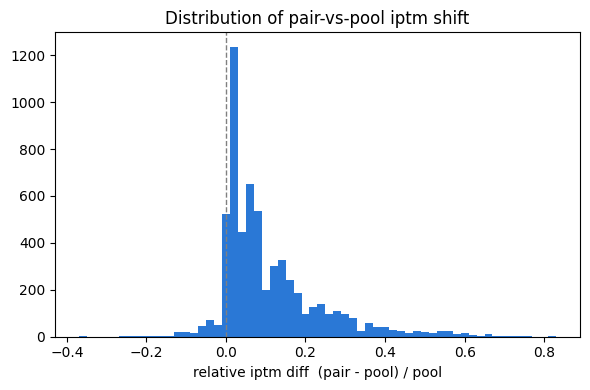

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pair_vs_pool["mean_iptm_diff"].drop_nulls(), bins=60, color="#2a78d6")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("relative iptm diff  (pair - pool) / pool")
ax.set_title("Distribution of pair-vs-pool iptm shift")
fig.tight_layout()


In [5]:
import polars as pl
from pathlib import Path

DIRS = {
    "26.04": Path("/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.04"),
    "26.07": Path("/cluster/work/beltrao/jjaenes/25.12_pooled-ppi-yeast/data-26.07"),
}

def pair_keys(data_dir: Path, homo: bool) -> set[str]:
    lf = pl.scan_parquet(data_dir / "summary_pairs.parquet")
    if "input_type" in lf.collect_schema().names():
        lf = lf.filter(pl.col("input_type") == "pair")
    lf = lf.select("af3_id1", "af3_id2")
    lf = lf.filter(pl.col("af3_id1") == pl.col("af3_id2")) if homo \
        else lf.filter(pl.col("af3_id1") != pl.col("af3_id2"))
    return set(
        lf.select(
            (pl.min_horizontal("af3_id1", "af3_id2") + "__" +
             pl.max_horizontal("af3_id1", "af3_id2")).alias("pair_id")
        ).unique().collect()["pair_id"]
    )

for kind, homo in [("homodimer", True), ("heterodimer", False)]:
    sets = {v: pair_keys(d, homo=homo) for v, d in DIRS.items()}
    only_04 = sets["26.04"] - sets["26.07"]
    only_07 = sets["26.07"] - sets["26.04"]
    print(f"\n{kind}: 26.04={len(sets['26.04'])} pairs, 26.07={len(sets['26.07'])} pairs")
    print(f"  only in 26.04: {len(only_04)}")
    print(f"  only in 26.07: {len(only_07)}")


homodimer: 26.04=0 pairs, 26.07=6039 pairs
  only in 26.04: 0
  only in 26.07: 6039

heterodimer: 26.04=10229611 pairs, 26.07=29936 pairs
  only in 26.04: 10200732
  only in 26.07: 1057


## Minimla example

In [10]:
#slevet only first 2 columns to sent to jürgen
coverage_df = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/scripts/homomultimers/minimal_working_example/coverage.csv")

In [12]:
coverage_df = coverage_df.select(["protein","verdict"])

In [13]:
coverage_df = coverage_df.with_columns(
    pl.col("verdict").str.to_lowercase()
)

In [14]:
coverage_df.write_csv("/cluster/project/beltrao/kdammer/master_thesis/scripts/homomultimers/minimal_working_example/summary_coverage.csv")

Does the table contain correcetd iptm? (and min PAE)

In [6]:
homodimers_iptm_PAE = pl.read_parquet(data_dir/"Homomltimer/homodimers_iptm_PAE.parquet")

In [11]:
t = list(homodimers_iptm_PAE.columns)

In [5]:
# 1. Check for an EXACT match (returns True or False)
"chain_pair_iptm_best_corrected" in homodimers_iptm_PAE.columns


True

In [5]:
CP_df = pl.read_csv(data_dir/ "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator = "\t")

## Chech min IPtM mapping

In [ ]:
import polars as pl

In [ ]:
pae_mapping = pl.read_parquet(data_dir/"iPTM_and_pLDDT/PAE/yeast_pairs_pae.parquet")

In [6]:
pae_mapping["complex_type"].value_counts()

complex_type,count
str,u32
"""heteromer""",25366192
"""homomer""",60390


In [ ]:
subset_pae = pae_mapping[:10]

In [4]:
subset_pae

protein_A,protein_B,input_type,seed,sample,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean,complex_type
str,str,str,i64,i64,f64,f64,f64,str
"""ebi-16716764""","""p47019""",null,null,null,null,null,null,"""heteromer"""
"""p46654""","""p53280""","""pool""",4,0,30.97,31.38,31.175,"""heteromer"""
"""p46654""","""p53280""","""pool""",4,1,31.06,31.36,31.21,"""heteromer"""
"""p46654""","""p53280""","""pool""",4,2,30.91,31.44,31.175,"""heteromer"""
"""p46654""","""p53280""","""pool""",4,3,30.9,31.37,31.135,"""heteromer"""
"""p46654""","""p53280""","""pool""",4,4,30.87,31.31,31.09,"""heteromer"""
"""p38175""","""p47058""","""pool""",4,0,30.81,31.43,31.12,"""heteromer"""
"""p38175""","""p47058""","""pool""",4,1,30.81,30.93,30.87,"""heteromer"""
"""p38175""","""p47058""","""pool""",4,2,30.9,31.49,31.195,"""heteromer"""


In [20]:
pae_mapping.columns

['protein_A',
 'protein_B',
 'input_type',
 'seed',
 'sample',
 'chain_pair_pae_min_min',
 'chain_pair_pae_min_max',
 'chain_pair_pae_min_mean']

In [4]:
pairs_parquet = pl.read_parquet(data_dir/"iPTM_and_pLDDT/iPTM/yeast_protein_pairs.parquet")

In [ ]:
homodimers = pae_mapping.join(pairs_parquet, on = ["protein_A", "protein_B"], how = "anti") # 10 times more rows than expected cause every homodimer pair has 10 modles

In [8]:
o13297_homodimer = pae_mapping.filter(pl.col("protein_A") == "o13297").filter(pl.col("protein_B") == "o13297")

In [9]:
o13297_homodimer

protein_A,protein_B,input_type,seed,sample,chain_pair_pae_min_min,chain_pair_pae_min_max,chain_pair_pae_min_mean,complex_type
str,str,str,i64,i64,f64,f64,f64,str
"""o13297""","""o13297""","""pair""",4,0,1.49,1.5,1.495,"""homomer"""
"""o13297""","""o13297""","""pair""",4,1,1.55,1.56,1.555,"""homomer"""
"""o13297""","""o13297""","""pair""",4,2,1.54,1.56,1.55,"""homomer"""
"""o13297""","""o13297""","""pair""",4,3,1.32,1.32,1.32,"""homomer"""
"""o13297""","""o13297""","""pair""",4,4,1.52,1.54,1.53,"""homomer"""
"""o13297""","""o13297""","""pool""",4,0,5.62,5.88,5.75,"""homomer"""
"""o13297""","""o13297""","""pool""",4,1,5.79,6.22,6.005,"""homomer"""
"""o13297""","""o13297""","""pool""",4,2,6.27,6.48,6.375,"""homomer"""
"""o13297""","""o13297""","""pool""",4,3,6.33,6.45,6.39,"""homomer"""


## Which protein pairs are in my pooled af database?

In [2]:
Pairs_per_prot_breakdown = pl.read_csv(PRJ_ROOT / "scripts/exploratory/proteins_in_heterodimers.csv")

In [8]:
Pairs_per_prot_breakdown.columns

['uniprot_id', 'af3_id', 'n_partners']

In [ ]:
(Pairs_per_prot_breakdown["n_partners"].sum()/2) - 10269735 #divided by 2 because every pair is counted twice (once for each protein) rest are homodimers


-6039.0

## How many pairs do I need to assmeble my complexes

In [3]:
pairs_AF_model_exists = pl.read_parquet(data_dir /'iPTM_and_pLDDT/CP_YM_complexes_unique_pairs_dedub_paralogue_cleaned_AF_model_exists.parquet')

In [5]:
pairs_AF_model_exists.head(2)

Protein_1,Protein_2,Complex_portal_complex,YM_complex,source,complex_ac,Para_exchange,Replaced_protein,AF_model_exists
str,str,str,str,str,str,str,str,bool
"""P38282""","""P53905""","""P19735 P20053 P23394 P32639 P3…","""P43321 P19736 P49955 Q03375 Q0…","""Complex_Portal & YeastMap""","""CPX-25""",null,null,true
"""P08518""","""Q07532""","""""","""P23615 P20436 P41895 P07273 P3…","""YeastMap""",null,null,null,true


In [12]:
no_pairs_exist = pairs_AF_model_exists.filter(
    ~pl.col("AF_model_exists")
)  # all pairs needed (including paralogue swaps)

Complex_no_pair = no_pairs_exist.filter(
    pl.col("source").str.contains("Complex_Portal")
    & pl.col("Replaced_protein").is_null()
)  # Complex Portal only, excluding paralogue swaps

complex_and_YM_no_pair = no_pairs_exist.filter(
    (pl.col("source").str.contains("Complex_Portal")
     | pl.col("source").str.contains("YeastMap"))
    & pl.col("Replaced_protein").is_null()
)  # Complex Portal + YeastMap, excluding paralogue swaps

print(f"no_pairs_exist: {no_pairs_exist.height}")
print(f"Complex_no_pair: {Complex_no_pair.height}")
print(f"complex_and_YM_no_pair: {complex_and_YM_no_pair.height}")

no_pairs_exist: 3878
Complex_no_pair: 2273
complex_and_YM_no_pair: 2934


add YM complex id and CP and YP id for pairs afetr para swap

In [4]:
Pair_AF_model_mapping = pl.read_parquet( data_dir/ 'iPTM_and_pLDDT/CP_YM_complexes_unique_pairs_dedub_paralogue_cleaned_AF_model_exists.parquet')


YM = pl.read_csv(data_dir /"Complex_Portal/YeastMap/yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv")
YM = make_pairs(YM, column ='UniProt_ACCs')  

'''
CP = pl.read_csv(data_dir /"Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator = '\t')
CP = make_pairs(clean_identifiers(CP), "Cleaned Identifiers")
'''

'\nCP = pl.read_csv(data_dir /"Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator = \'\t\')\nCP = make_pairs(clean_identifiers(CP), "Cleaned Identifiers")\n'

In [5]:
# ensure pairs are in correct order
YM = YM.with_columns(
    pl.concat_str(
        [pl.min_horizontal("Protein_1", "Protein_2"),
         pl.max_horizontal("Protein_1", "Protein_2")],
        separator="_"
    ).alias("pair_id")
)

Pair_AF_model_mapping = Pair_AF_model_mapping.with_columns(
    pl.concat_str(
        [pl.min_horizontal("Protein_1", "Protein_2"),
         pl.max_horizontal("Protein_1", "Protein_2")],
        separator="_"
    ).alias("pair_id")
)

# collapse YM to one row per pair, IDs joined with " | "
YM_collapsed = (
    YM.group_by("pair_id")
    .agg(pl.col("yeastMAP_ID").sort().str.join(" | "))
)

# join on pair_id (not on Protein_1/Protein_2)
Pair_AF_model_mapping = Pair_AF_model_mapping.join(
    YM_collapsed,
    on="pair_id",
    how="left",
)

In [6]:
Pair_AF_model_mapping = Pair_AF_model_mapping.select([
    "Protein_1",
    "Protein_2",
    "Complex_portal_complex",
    "YM_complex",
    "source",
    "complex_ac",
    "yeastMAP_ID", 
    "Para_exchange",
    "Replaced_protein",
    "AF_model_exists",
    "pair_id",
])

In [7]:
Pair_AF_model_mapping.write_parquet(data_dir /'iPTM_and_pLDDT/final_CP_YM_complexes_pairs_AF_model_exists.parquet')

Heteroddimer Pairs i need AF to be run against

In [8]:
Pair_AF_model_mapping = pl.read_parquet( data_dir/ 'iPTM_and_pLDDT/final_CP_YM_complexes_pairs_AF_model_exists.parquet')

In [9]:
Pair_AF_model_mapping_resubmitt = Pair_AF_model_mapping.filter(pl.col("AF_model_exists") == False)
Pair_AF_model_mapping_resubmitt.write_parquet(data_dir /'iPTM_and_pLDDT/Heterodimers_to_rereun_AF/CP_YM_complexes_pairs_rerun_AF.parquet')